In [46]:
import pandas as pd
import numpy as np
import copy

# Define class
Define class that can give and receive a currency

In [47]:
class EconAgent:
    def __init__(self, identity, money):
        self.identity = identity
        # self.position = position
        self.money = money

    # def updatePosition(self):
    #     self.position = np.random.randint(1,10)

    def giveMoney(self, value = 1):
        self.money -= 1

    def getMoney(self, value = 1):
        self.money += 1

In [48]:
(np.random.pareto(1)) * 10

100.31791526369824

# Create Population

In [49]:
def createPopulation(N):
    population = {}

    for i in range(N):
        
        initial_wealth = 10 # Equal distribution
        # initial_wealth = np.round(np.random.normal(10, 1)) # Normal distribution
        # initial_wealth = (np.random.pareto(1.5)) * 10 # Pareto distribution

        agent = EconAgent(i, initial_wealth)
        population[i] = {"identity": agent.identity, 
                         "money": agent.money}

    return population

def choosePair(population):
    i, j = np.random.choice(len(population), 2, replace=False)
    return population[i], population[j]

# Define the population

In [50]:
pop = createPopulation(100)
print(pop)
choosePair(pop)

{0: {'identity': 0, 'money': 10}, 1: {'identity': 1, 'money': 10}, 2: {'identity': 2, 'money': 10}, 3: {'identity': 3, 'money': 10}, 4: {'identity': 4, 'money': 10}, 5: {'identity': 5, 'money': 10}, 6: {'identity': 6, 'money': 10}, 7: {'identity': 7, 'money': 10}, 8: {'identity': 8, 'money': 10}, 9: {'identity': 9, 'money': 10}, 10: {'identity': 10, 'money': 10}, 11: {'identity': 11, 'money': 10}, 12: {'identity': 12, 'money': 10}, 13: {'identity': 13, 'money': 10}, 14: {'identity': 14, 'money': 10}, 15: {'identity': 15, 'money': 10}, 16: {'identity': 16, 'money': 10}, 17: {'identity': 17, 'money': 10}, 18: {'identity': 18, 'money': 10}, 19: {'identity': 19, 'money': 10}, 20: {'identity': 20, 'money': 10}, 21: {'identity': 21, 'money': 10}, 22: {'identity': 22, 'money': 10}, 23: {'identity': 23, 'money': 10}, 24: {'identity': 24, 'money': 10}, 25: {'identity': 25, 'money': 10}, 26: {'identity': 26, 'money': 10}, 27: {'identity': 27, 'money': 10}, 28: {'identity': 28, 'money': 10}, 29: 

({'identity': 13, 'money': 10}, {'identity': 99, 'money': 10})

In [51]:
print(pop)

{0: {'identity': 0, 'money': 10}, 1: {'identity': 1, 'money': 10}, 2: {'identity': 2, 'money': 10}, 3: {'identity': 3, 'money': 10}, 4: {'identity': 4, 'money': 10}, 5: {'identity': 5, 'money': 10}, 6: {'identity': 6, 'money': 10}, 7: {'identity': 7, 'money': 10}, 8: {'identity': 8, 'money': 10}, 9: {'identity': 9, 'money': 10}, 10: {'identity': 10, 'money': 10}, 11: {'identity': 11, 'money': 10}, 12: {'identity': 12, 'money': 10}, 13: {'identity': 13, 'money': 10}, 14: {'identity': 14, 'money': 10}, 15: {'identity': 15, 'money': 10}, 16: {'identity': 16, 'money': 10}, 17: {'identity': 17, 'money': 10}, 18: {'identity': 18, 'money': 10}, 19: {'identity': 19, 'money': 10}, 20: {'identity': 20, 'money': 10}, 21: {'identity': 21, 'money': 10}, 22: {'identity': 22, 'money': 10}, 23: {'identity': 23, 'money': 10}, 24: {'identity': 24, 'money': 10}, 25: {'identity': 25, 'money': 10}, 26: {'identity': 26, 'money': 10}, 27: {'identity': 27, 'money': 10}, 28: {'identity': 28, 'money': 10}, 29: 

In [52]:
history = {}
history[0] = copy.deepcopy(pop)

for t in range(1, 5000):

    giver, receiver = choosePair(pop)

    epsilon = np.random.random()
    delta = epsilon * giver['money']

    giverAgent = EconAgent(giver.get('identity'), giver.get('money'))
    giverAgent.giveMoney(delta)

    receiverAgent = EconAgent(receiver.get('identity'), receiver.get('money'))
    receiverAgent.getMoney(delta)

    pop[giver.get('identity')] = {
        "identity": giverAgent.identity,
        "money": giverAgent.money
    }

    pop[receiver['identity']] = {
        "identity": receiverAgent.identity,
        "money": receiverAgent.money
    }

    history[t] = copy.deepcopy(pop)

In [53]:
history_df = pd.DataFrame()
for t in history:
    # print(t)
    data = history[t]
    df = pd.DataFrame.from_dict(data, orient="index")
    df['time'] = t

    history_df = pd.concat([history_df, df])
    
history_df = history_df.reset_index()

In [54]:
history_df.loc[history_df['identity'] == 1].head(20)

,index,identity,money,time
1,1,1,10,0
101,1,1,10,1
201,1,1,10,2
301,1,1,10,3
401,1,1,10,4
501,1,1,10,5
601,1,1,10,6
701,1,1,10,7
801,1,1,10,8
901,1,1,10,9


In [55]:
import matplotlib.pyplot as plt

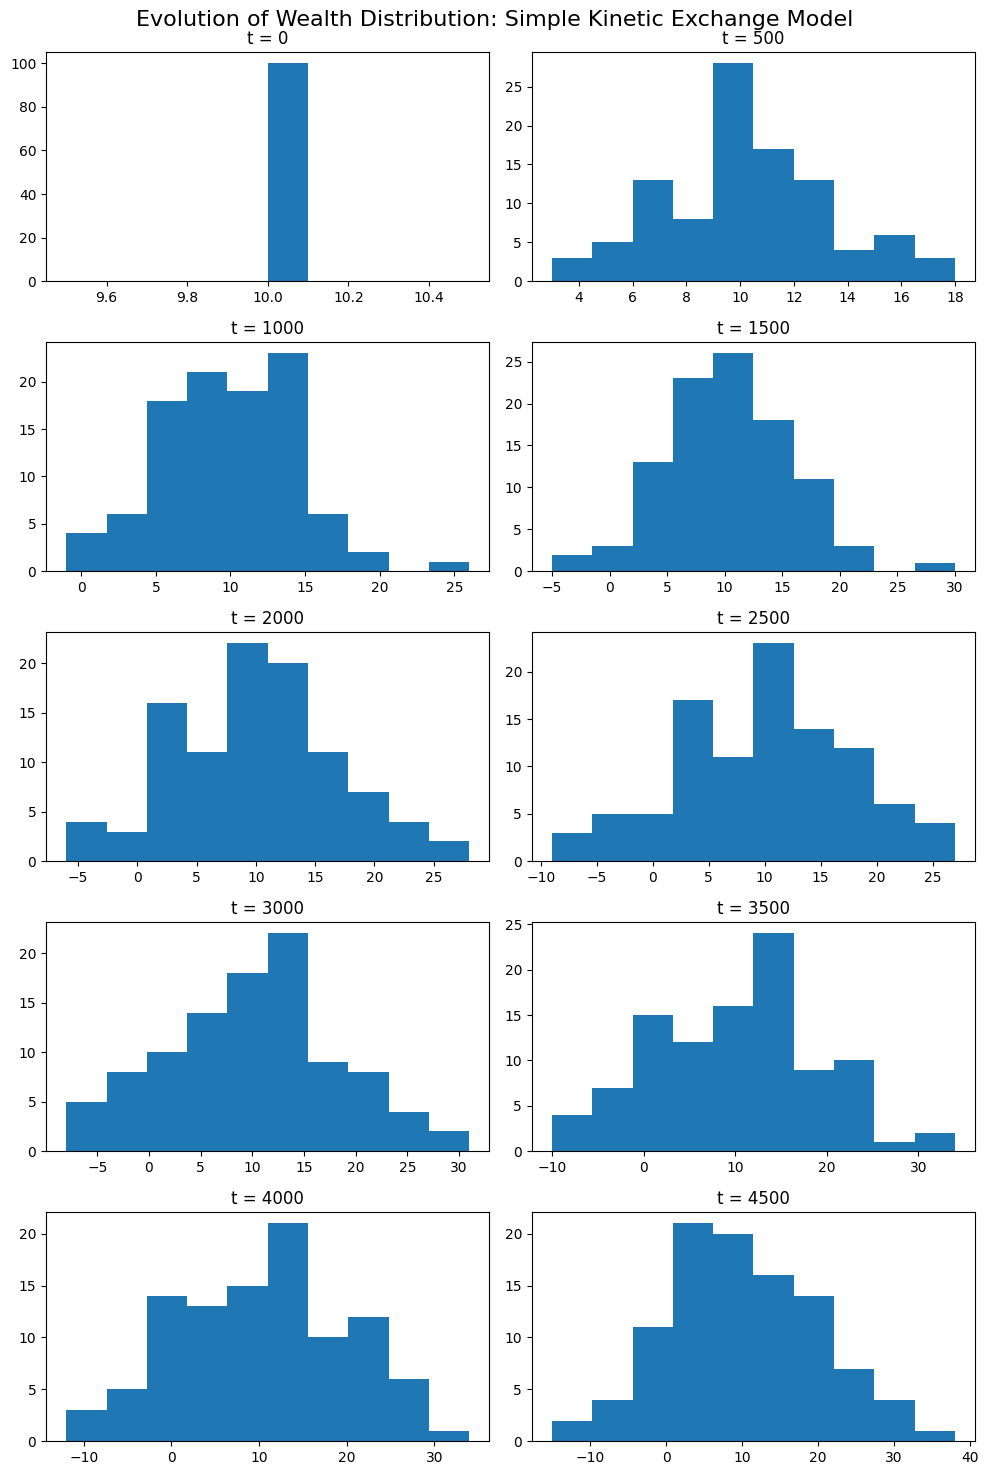

In [56]:
fig, ax = plt.subplots(5, 2, figsize=(10, 15))

times_to_plot = range(0, 5010, 500)  # 0,5,10,...,45

for axis, t in zip(ax.flat, times_to_plot):
    data_t = history_df[history_df["time"] == t]["money"]
    axis.hist(data_t)
    axis.set_title(f"t = {t}")

fig.suptitle('Evolution of Wealth Distribution: Simple Kinetic Exchange Model', fontsize=16)
plt.tight_layout()
plt.show()